In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET
import os
import typing
import numpy as np
SUMO_START_TIME = 28800
# Increase font sizes globally
mpl.rcParams['axes.titlesize'] = 40
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['figure.titlesize'] = 30
# line width
mpl.rcParams['lines.linewidth'] = 4



def get_acceleration_distance(data_dic):
    for pr in data_dic:
        profile = data_dic[pr]['ego_profile']
        profile[profile['ActualSpeed'] < 0]['ActualSpeed'] = 0
        profile['Acceleration'] = profile['ActualSpeed'].diff()

        # fill the nan value with 0
        profile['Acceleration'] = profile['Acceleration'].fillna(0)

        for group_name, group in profile.groupby('TripId'):
            # claculate the energy consumption first Fuel Consumption = integral of Fuel vol flow rate
            energy_consumption = group['BatteryPower'] * group['Time'].diff().fillna(1)
            energy_consumption = energy_consumption.cumsum()
            energy_consumption_total = energy_consumption.iloc[-1] * 264.172 # convert to gallon
            # take the direction of the trip
            direction = group['Direction'].iloc[0]

            # calculate the per trip distance
            time = group['Time'] - group['Time'].iloc[0]
            distance = group['ActualSpeed'] * time.diff().fillna(1)
            distance = distance.cumsum()
            # set the distance for the trip
            profile.loc[profile['TripId'] == group_name, 'TravelDistance'] = distance
        profile['TravelDistance'] = profile['TravelDistance'].fillna(0)
        data_dic[pr]['ego_profile'] = profile
    return data_dic

In [21]:
def assign_trip_id(df, distance_threshold):
        for veh_id, group in df.groupby('id'):
            group['tripId'] = (abs(group['distance'].diff()) > distance_threshold).cumsum()
            df.loc[df['id'] == veh_id, 'tripId'] = group['tripId']

        return df
def get_data_dics(path):
    root_dir = os.getcwd()
    # '.\\Experiments\\AC'
    working_dir = os.path.join(root_dir, path)
    seting_dirs = os.listdir(working_dir)

    data_dic_with_dynamics = typing.DefaultDict(dict)
    data_dic_without_dynamics = typing.DefaultDict(dict)
    for idx, setting_dir in enumerate(seting_dirs):

        print(f'Processing {setting_dir}')
        penetration_rate = float(setting_dir.split('_')[0][:-1])

        sumo_signal_config = pd.read_csv(os.path.join(working_dir, setting_dir, '.\\sumoSignalConfig_26.csv'), index_col=0)
        sumo_signal_config['id'] = sumo_signal_config['id'].astype(str)
        # Calculate the relative distance for each point
        refer_coord_wb = [1380, 225]
        refer_coord_eb = [230, 705]
        sumo_signal_config['distance_wb'] = np.sqrt((sumo_signal_config['x'] - refer_coord_wb[0]) ** 2 + (sumo_signal_config['y'] - refer_coord_wb[1]) ** 2)
        sumo_signal_config['distance_eb'] = np.sqrt((sumo_signal_config['x'] - refer_coord_eb[0]) ** 2 + (sumo_signal_config['y'] - refer_coord_eb[1]) ** 2)

        if '_D' in setting_dir:
            ego_profile = pd.read_csv(os.path.join(working_dir, setting_dir, '.\\ego_profile.csv'))
            ego_profile['Time'] = ego_profile['Time'].astype(float)
            data_dic_with_dynamics[penetration_rate]['ego_profile'] = ego_profile
            data_dic_with_dynamics[penetration_rate]['sumo_signal_config'] = sumo_signal_config
            data_dic_with_dynamics[penetration_rate]['path'] = os.path.join(working_dir, setting_dir)

        else:
            ego_profile = pd.read_csv(os.path.join(working_dir, setting_dir, '.\\ego_profile.csv'))
            ego_profile['Time'] = ego_profile['Time'].astype(float)
            data_dic_without_dynamics[penetration_rate]['ego_profile'] = ego_profile
            data_dic_without_dynamics[penetration_rate]['sumo_signal_config'] = sumo_signal_config
            data_dic_without_dynamics[penetration_rate]['path'] = os.path.join(working_dir, setting_dir)
    return dict(sorted(data_dic_with_dynamics.items())), dict(sorted(data_dic_without_dynamics.items()))

data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration = get_data_dics('.\\Experiments\\BC')
data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration = get_data_dics('.\\Experiments\\ACV2')

Processing 0%_1Hz_E
Processing 0%_1Hz_E_D_EV_longitude
Processing 10%_1Hz_E
Processing 10%_1Hz_E_D_EV_longitude
Processing 100%_1Hz_E
Processing 100%_1Hz_E_D_EV_longitude
Processing 20%_1Hz_E
Processing 20%_1Hz_E_D_EV_longitude
Processing 50%_1Hz_E
Processing 50%_1Hz_E_D_EV_longitude
Processing 0%_1Hz_E
Processing 0%_1Hz_E_D_EV_longitude
Processing 10%_1Hz_E
Processing 10%_1Hz_E_D_EV_longitude
Processing 100%_1Hz_E
Processing 100%_1Hz_E_D_EV_longitude
Processing 20%_1Hz_E
Processing 20%_1Hz_E_D_EV_longitude
Processing 50%_1Hz_E
Processing 50%_1Hz_E_D_EV_longitude


In [ ]:

import numpy as np
import seaborn as sns
from cav_casestudy.SUMO.spaceTimePlotWithSignals import remove_none_edges
from cav_casestudy.SUMO.VehicleEnergyEvaluation import get_traj_eval
from cav_casestudy.SUMO.utils1 import vtcpmf_fuel_model, energyVTMicro, cal_trac_energy
import time
import pandas as pd




import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_system_eval(data_dic_with_dynamics_before_calibration,
                     data_dic_with_dynamics_after_calibration):

    system_mpg_cpmf_dict = {}

    def get_direction_eval(penetration_rate, data_dic, vtMicroCoeff, df_vehicle_src_coeff, direction):
        trajectory_data = data_dic[penetration_rate][f'trajectory_data_{direction}']
        _, fuel_list, _, _, _, _, dist_list, _ = get_traj_eval(
            trajectory_data, 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')

        mpg_list = []
        for f, d in zip(fuel_list, dist_list):
            dist_miles = d / 1609.34
            fuel_gallon = f / 3.78541
            mpg = dist_miles / fuel_gallon if fuel_gallon > 0 else 0
            mpg_list.append(mpg)

        return mpg_list

    for penetration_rate in data_dic_with_dynamics_before_calibration.keys():
        vtMicroCoeff = pd.read_csv('VTMicroCoeff.csv')
        df_vehicle_src_coeff = pd.read_csv('VehicleSrcCoeff.csv')

        mpg_dict = {}
        for label, data_dic in [
            ('Before Calibration', data_dic_with_dynamics_before_calibration),
            ('After Calibration', data_dic_with_dynamics_after_calibration)
        ]:
            mpg_dict[f'{label} - WB'] = get_direction_eval(penetration_rate, data_dic, vtMicroCoeff, df_vehicle_src_coeff, 'wb')
            mpg_dict[f'{label} - EB'] = get_direction_eval(penetration_rate, data_dic, vtMicroCoeff, df_vehicle_src_coeff, 'eb')

        system_mpg_cpmf_dict[penetration_rate] = mpg_dict

    def plot_direction_boxplot(direction):
        labels = []
        box_data = []
        means = []
        stds = []
        positions = []
        pos = 1
        color_map = {
            'Before Calibration': '#FF9999',
            'After Calibration': '#99CCFF'
        }

        for penetration_rate in sorted(system_mpg_cpmf_dict.keys()):
            mpg_dict = system_mpg_cpmf_dict[penetration_rate]
            for condition in ['Before Calibration', 'After Calibration']:
                key = f'{condition} - {direction}'
                mpg_values = mpg_dict[key]
                box_data.append(mpg_values)
                labels.append(f'{penetration_rate*100:.0f}%\n{condition}')
                means.append(np.mean(mpg_values))
                stds.append(np.std(mpg_values))
                positions.append(pos)
                pos += 1
            pos += 1  # Space between penetration groups

        # Plot
        fig, ax = plt.subplots(figsize=(14, 6))
        bp = ax.boxplot(box_data, positions=positions, patch_artist=True, widths=0.6)

        # Box styling
        for patch, label in zip(bp['boxes'], labels):
            if 'Before' in label:
                patch.set_facecolor(color_map['Before Calibration'])
            else:
                patch.set_facecolor(color_map['After Calibration'])
            patch.set_alpha(0.7)

        # Error bars
        ax.errorbar(positions, means, yerr=stds, fmt='o', color='black', capsize=5, label='Mean ± Std')

        # Ticks and labels
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Miles per Gallon (MPG)', fontsize=14)
        ax.set_title(f'System Fuel Efficiency (MPG) – {direction.upper()} Only', fontsize=16)

        ax.set_ylim(0, 50)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Generate separate plots
    plot_direction_boxplot('WB')
    plot_direction_boxplot('EB')


plot_system_eval(data_dic_with_dynamics_before_calibration, data_dic_with_dynamics_after_calibration)


In [ ]:
# def plot_system_eval(data_dic_with_dynamics, data_dic_without_dynamics):
#     system_mpg_cpmf_dict = {}
#     def get_round_trip_eval(penetration_rate, data_dic, vtMicroCoeff, df_vehicle_src_coeff):
#         trajectory_data_wb = data_dic[penetration_rate]['trajectory_data_wb']
#         trajectory_data_eb = data_dic[penetration_rate]['trajectory_data_eb']
#         _, system_fuel_consume_vt_cpmf_liter_wb, system_fuel_consume_vt_micro_liter_wb, _,_, _, system_travel_dist2_m_wb, _ = get_traj_eval(trajectory_data_wb, 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')
#         _, system_fuel_consume_vt_cpmf_liter_eb, system_fuel_consume_vt_micro_liter_eb, _,_, _, system_travel_dist2_m_eb, _ = get_traj_eval(trajectory_data_eb, 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')

#         system_fuel_efficiency_cpmf_mpg = ((system_travel_dist2_m_wb + system_travel_dist2_m_eb) / 1609.34) / ((system_fuel_consume_vt_cpmf_liter_wb + system_fuel_consume_vt_cpmf_liter_eb) / 3.78541)
        
#         return system_fuel_efficiency_cpmf_mpg
    
#     for penetration_rate, _ in data_dic_with_dynamics.items():

#         vtMicroCoeff = pd.read_csv(r'VTMicroCoeff.csv')
#         df_vehicle_src_coeff = pd.read_csv(r'VehicleSrcCoeff.csv')
        
#         system_fuel_efficiency_cpmf_mpg_with_dynamics = get_round_trip_eval(penetration_rate, data_dic_with_dynamics, vtMicroCoeff, df_vehicle_src_coeff)
#         system_fuel_efficiency_cpmf_mpg_without_dynamics = get_round_trip_eval(penetration_rate, data_dic_without_dynamics, vtMicroCoeff, df_vehicle_src_coeff)
       
#         system_mpg_cpmf_dict[penetration_rate] = {'With Vehicle Dynamics': system_fuel_efficiency_cpmf_mpg_with_dynamics,
#                                                   'Without Vehicle Dynamics': system_fuel_efficiency_cpmf_mpg_without_dynamics,
#         }
    

#     # Visualization
#     fig, ax = plt.subplots(1, 1, figsize=(12, 6))
#     penetration_rates = list(system_mpg_cpmf_dict.keys())

#     # Extract MPG values
#     mpg_with_dynamics_before = [system_mpg_cpmf_dict[pr]['With Vehicle Dynamics'] for pr in penetration_rates]
#     mpg_without_dynamics_before = [system_mpg_cpmf_dict[pr]['Without Vehicle Dynamics'] for pr in penetration_rates]

#     # Define Colors (Before vs. After Calibration)
#     colors = {
#         "Before Calibration": "red",  
#         "After Calibration": "blue"    
#     }

#     # Define Markers (With vs. Without Dynamics)
#     markers = {
#         "With Dynamics": "o",   # Circle
#         "Without Dynamics": "s" # Square
#     }

#     # Plot Data
#     ax.plot(penetration_rates, mpg_with_dynamics_before, color=colors["After Calibration"], linestyle='--', marker=markers["With Dynamics"], markersize=8, linewidth=2, label='With Vehicle Dynamics')
#     ax.plot(penetration_rates, mpg_without_dynamics_before, color=colors["After Calibration"], linestyle='-', marker=markers["Without Dynamics"], markersize=8, linewidth=2, label='Without Vehicle Dynamics')
    
   
#     # Labels and title
#     ax.set_xlabel('Penetration Rate (%)', fontsize=14)
#     ax.set_ylabel('Miles per Gallon (MPG)', fontsize=14)
#     ax.set_title('System Fuel Efficiency (MPG) With and Without Calibration', fontsize=16)

#     # Grid and legend
#     ax.grid(True, linestyle='--', alpha=0.6)
#     ax.legend(fontsize=12, loc='best')

#     plt.tight_layout()
#     plt.show()
# plot_system_eval(data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration)

In [ ]:
from cav_casestudy.SUMO.VehicleEnergyEvaluation import get_traj_eval
refer_coord_wb = [1380, 225]
refer_coord_eb = [230, 705]
def plot_system_eval(data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration, data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration):
    system_mpg_cpmf_dict = {}
    def get_round_trip_eval(penetration_rate, data_dic, vtMicroCoeff, df_vehicle_src_coeff):
        path = data_dic[penetration_rate]['path']
        # trajectory_data_wb = data_dic[penetration_rate]['trajectory_data_wb']
        # trajectory_data_eb = data_dic[penetration_rate]['trajectory_data_eb']
        _, system_fuel_consume_vt_cpmf_liter_wb, system_fuel_consume_vt_micro_liter_wb, _, _, _, _, system_travel_dist2_m_wb, _ = get_traj_eval(path, 1, vtMicroCoeff, df_vehicle_src_coeff, refer_coord=refer_coord_wb,direction='WB',veh_no='system')
        # _, system_fuel_consume_vt_cpmf_liter_eb, system_fuel_consume_vt_micro_liter_eb, _,_, _, system_travel_dist2_m_eb, _ = get_traj_eval(trajectory_data_eb, 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')
        
        # system_fuel_efficiency_cpmf_mpg = ((system_travel_dist2_m_wb + system_travel_dist2_m_eb) / 1609.34) / ((system_fuel_consume_vt_cpmf_liter_wb + system_fuel_consume_vt_cpmf_liter_eb) / 3.78541)
        system_fuel_efficiency_cpmf_mpg = ((system_travel_dist2_m_wb) / 1609.34) / ((system_fuel_consume_vt_cpmf_liter_wb) / 3.78541)
        
        return system_fuel_efficiency_cpmf_mpg
    
    for penetration_rate, _ in data_dic_with_dynamics_before_calibration.items():

        vtMicroCoeff = pd.read_csv(r'VTMicroCoeff.csv')
        df_vehicle_src_coeff = pd.read_csv(r'VehicleSrcCoeff.csv')
        
        system_fuel_efficiency_cpmf_mpg_with_dynamics_before_calibration = get_round_trip_eval(penetration_rate, data_dic_with_dynamics_before_calibration, vtMicroCoeff, df_vehicle_src_coeff)
        system_fuel_efficiency_cpmf_mpg_without_dynamics_before_calibration = get_round_trip_eval(penetration_rate, data_dic_without_dynamics_before_calibration, vtMicroCoeff, df_vehicle_src_coeff)
        system_fuel_efficiency_cpmf_mpg_with_dynamics_after_calibration = get_round_trip_eval(penetration_rate, data_dic_with_dynamics_after_calibration, vtMicroCoeff, df_vehicle_src_coeff)
        system_fuel_efficiency_cpmf_mpg_without_dynamics_after_calibration = get_round_trip_eval(penetration_rate, data_dic_without_dynamics_after_calibration, vtMicroCoeff, df_vehicle_src_coeff)

        system_mpg_cpmf_dict[penetration_rate] = {'Before Calibration (With Vehicle Dynamics)': system_fuel_efficiency_cpmf_mpg_with_dynamics_before_calibration,
                                                  'Before Calibration (Without Vehicle Dynamics)': system_fuel_efficiency_cpmf_mpg_without_dynamics_before_calibration,
                                                  'After Calibration (With Vehicle Dynamics)': system_fuel_efficiency_cpmf_mpg_with_dynamics_after_calibration,
                                                  'After Calibration (Without Vehicle Dynamics)': system_fuel_efficiency_cpmf_mpg_without_dynamics_after_calibration}
    

    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    penetration_rates = list(system_mpg_cpmf_dict.keys())

    # Extract MPG values
    mpg_with_dynamics_before = [system_mpg_cpmf_dict[pr]['Before Calibration (With Vehicle Dynamics)'] for pr in penetration_rates]
    mpg_without_dynamics_before = [system_mpg_cpmf_dict[pr]['Before Calibration (Without Vehicle Dynamics)'] for pr in penetration_rates]
    mpg_with_dynamics_after = [system_mpg_cpmf_dict[pr]['After Calibration (With Vehicle Dynamics)'] for pr in penetration_rates]
    mpg_without_dynamics_after = [system_mpg_cpmf_dict[pr]['After Calibration (Without Vehicle Dynamics)'] for pr in penetration_rates]

    # Define Colors (Before vs. After Calibration)
    colors = {
        "Before Calibration": "red",  
        "After Calibration": "blue"    
    }

    # Define Markers (With vs. Without Dynamics)
    markers = {
        "With Dynamics": "o",   # Circle
        "Without Dynamics": "s" # Square
    }

    # Plot Data
    ax.plot(penetration_rates, mpg_with_dynamics_before, color=colors["Before Calibration"], linestyle='--', marker=markers["With Dynamics"], markersize=8, linewidth=2, label='Before Calibration (With Vehicle Dynamics)')
    ax.plot(penetration_rates, mpg_without_dynamics_before, color=colors["Before Calibration"], linestyle='-', marker=markers["Without Dynamics"], markersize=8, linewidth=2, label='Before Calibration (Without Vehicle Dynamics)')
    
    ax.plot(penetration_rates, mpg_with_dynamics_after, color=colors["After Calibration"], linestyle='--', marker=markers["With Dynamics"], markersize=8, linewidth=2, label='After Calibration (With Vehicle Dynamics)')
    ax.plot(penetration_rates, mpg_without_dynamics_after, color=colors["After Calibration"], linestyle='-', marker=markers["Without Dynamics"], markersize=8, linewidth=2, label='After Calibration (Without Vehicle Dynamics)')

    # Labels and title
    ax.set_xlabel('Penetration Rate (%)', fontsize=14)
    ax.set_ylabel('Miles per Gallon (MPG)', fontsize=14)
    ax.set_title('System Fuel Efficiency (MPG) Before and After Calibration', fontsize=16)

    # Grid and legend
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=12, loc='best')

    plt.tight_layout()
    plt.show()

In [ ]:
plot_system_eval(data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration, data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration)

C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\3532892955.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['distance'] = data['Time'].map(data_wb.set_index('time')['distance'])
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\3532892955.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['id'] = 'ego'
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\2128674271.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

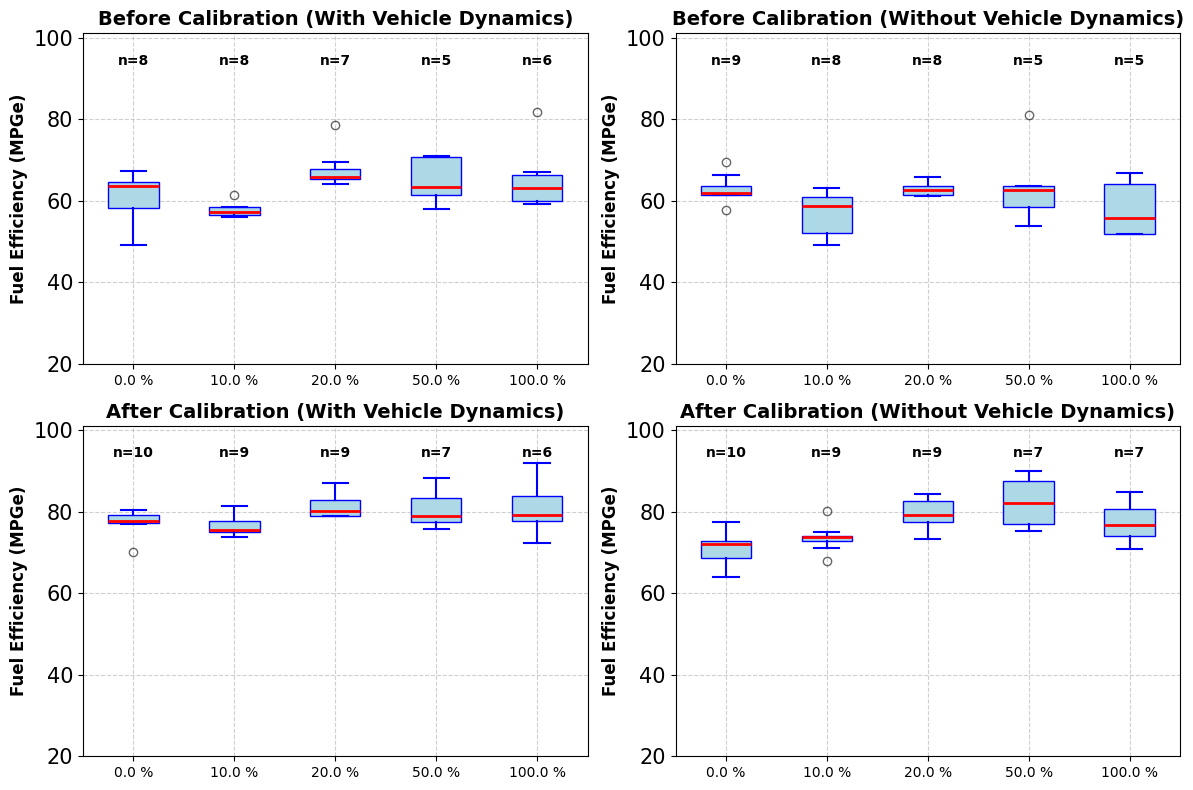

In [23]:
def getEVenergy(v, a):
    # Input:
    #   v: speed in m/s
    #   a: acceleration in m/s^2
    # Output:
    #   batteryPowerKw: battery power in kW
    #
    #   after getting power of each (v,a), multiply all battery power with delta time: batteryTotalKwh=sum(batteryPowerKw*dt/3600)
    #   after getting batteryTotalKwh, calculate equivalent gallon as batteryGallonEquivalent = batteryTotalKwh/33.7
    #   then can calculate MPGe using MPGe=distanceTotalMile/batteryGallonEquivalent
    p00 = 6.3331
    p10 = 0.6529
    p01 = 0.5910
    p20 = 0.0239
    p11 = 1.8354
    batteryPowerKw = p00 + p10*v + p01*a + p20*v**2 + p11*v*a
    return batteryPowerKw 

from cav_casestudy.SUMO.spaceTimePlotWithSignals import read_trajectory_xml, trajectory_process

def get_energy_consumption(inupt_data_dic, direction = 'WB', simulink=True):
    
    trip_counts = []
    trip_data_all = []
    trip_labels = []
    vtMicroCoeff = pd.read_csv(r'VTMicroCoeff.csv')
    df_vehicle_src_coeff = pd.read_csv(r'VehicleSrcCoeff.csv')
    for penetration_rate, data_dic in inupt_data_dic.items():
        if simulink:
            relative_time = 28800
            ego_profile = data_dic['ego_profile']
            ego_profile['Time'] = ego_profile['Time'].astype(float) + 28985 - relative_time
            
            # align the start time 
            path = data_dic['path']
            data_wb = read_trajectory_xml(os.path.join(path, 'fcd.xml'), refer_coord=refer_coord_wb)
        
            wb_lanes = ['-2801', '-280', '-307', '-327', '-281', '-315', '-321', '-300', '-2851', '-285', '-290', '-298', '-295']
            eb_lanes = ['-312', '-293', '-297', '-288', '-286', '-302', '-3221', '-322', '-313', '-284', '-328', '-304']
            
        
        
            data_wb = trajectory_process(data_wb, eb_lanes, wb_lanes, relative_time)
            data_wb = data_wb[data_wb['direction'] == 'WB']
            data_wb = data_wb[data_wb['id'] == 'ego']
            data_wb['time'] = data_wb['time'].astype(float)
            
            ego_profile['Direction'] = np.where(ego_profile['Time'].isin(data_wb['time']), 'WB', 'EB')

            if direction == 'WB':
                data = ego_profile[ego_profile['Direction'] == 'WB']
                
                data['distance'] = data['Time'].map(data_wb.set_index('time')['distance'])
                
            else:
                data = ego_profile[ego_profile['Direction'] == 'EB']
                data['distance'] = data['Time'].map(data_dic['trajectory_data_eb'].set_index('time')['distance'])
        
        data['id'] = 'ego'
        data = assign_trip_id(data, 100)
        trip_labels.append(f'{penetration_rate} %')
        trip_data = []
        for trip_id, group in data.groupby('tripId'):
            if simulink:
                mpge = group['MPGe']
                trip_data.append(mpge.iloc[-1])

        trip_data_all.append(trip_data)
        trip_counts.append(len(trip_data))
        

    return trip_data_all, trip_counts, trip_labels


# TODO: Test the function on the data
def plot_fuel_consumption_(data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration, data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration , simulink=True):
    # Extract trip data and labels
    # trip_data_before_calibration_with_dynamics -- list
    trip_data_before_calibration_with_dynamics, trip_counts_before_calibration_with_dynamics, trip_labels_before_calibration_with_dynamics = get_energy_consumption(data_dic_with_dynamics_before_calibration, simulink=simulink)
    trip_data_before_calibration_without_dynamics, trip_counts_before_calibration_without_dynamics, trip_labels_before_calibration_without_dynamics = get_energy_consumption(data_dic_without_dynamics_before_calibration, simulink=simulink)
    
    trip_data_after_calibration_with_dynamics, trip_counts_after_calibration_with_dynamics, trip_labels_after_calibration_with_dynamics = get_energy_consumption(data_dic_with_dynamics_after_calibration, simulink=simulink)
    trip_data_after_calibration_without_dynamics, trip_counts_after_calibration_without_dynamics, trip_labels_after_calibration_without_dynamics = get_energy_consumption(data_dic_without_dynamics_after_calibration, simulink=simulink)
    # Calculate global y-axis limits
    all_trip_data = trip_data_before_calibration_with_dynamics + trip_data_before_calibration_without_dynamics + trip_data_after_calibration_with_dynamics + trip_data_after_calibration_without_dynamics
    # y_min, y_max = min(map(min, all_trip_data)) * 0.9, max(map(max, all_trip_data)) * 1.1  # Adding buffer for clarity
    y_min, y_max = 20, max(map(max, all_trip_data)) * 1.1  # Adding buffer for clarity
    # use persentile to set the y axis limit
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    # fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Define function to create boxplots
    def create_boxplot(ax, trip_data, trip_labels, title, trip_counts):
        boxplot = ax.boxplot(
            trip_data,
            tick_labels=trip_labels,
            patch_artist=True,  # Fill the boxes with color
            boxprops=dict(facecolor='lightblue', color='blue'),  # Box properties
            medianprops=dict(color='red', linewidth=2),  # Median line properties
            whiskerprops=dict(color='blue', linewidth=1.5),  # Whisker properties
            capprops=dict(color='blue', linewidth=1.5),  # Cap properties
            flierprops=dict(marker='o', color='red', alpha=0.6)  # Outlier properties
        )
        ax.set_ylabel('Fuel Efficiency (MPGe)', fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_ylim(y_min, y_max)  # Set uniform y-axis limits

        # Add sample sizes as annotations
        for i, count in enumerate(trip_counts):
            ax.text(i + 1, y_max * 0.95, f'n={count}', ha='center', va='top', fontweight='bold', fontsize=10)

    # Create four boxplots
    create_boxplot(axes[0, 0], trip_data_before_calibration_with_dynamics, trip_labels_before_calibration_with_dynamics, 'Before Calibration (With Vehicle Dynamics)', trip_counts_before_calibration_with_dynamics)
    create_boxplot(axes[0, 1], trip_data_before_calibration_without_dynamics, trip_labels_before_calibration_without_dynamics, 'Before Calibration (Without Vehicle Dynamics)', trip_counts_before_calibration_without_dynamics)
    create_boxplot(axes[1, 0], trip_data_after_calibration_with_dynamics, trip_labels_after_calibration_with_dynamics, 'After Calibration (With Vehicle Dynamics)', trip_counts_after_calibration_with_dynamics)
    create_boxplot(axes[1, 1], trip_data_after_calibration_without_dynamics, trip_labels_after_calibration_without_dynamics, 'After Calibration (Without Vehicle Dynamics)', trip_counts_after_calibration_without_dynamics)


    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

plot_fuel_consumption_(data_dic_with_dynamics_before_calibration, data_dic_without_dynamics_before_calibration, data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration)

C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\820437216.py:55: UserWarning: 
The palette list has fewer values (1) than needed (1060) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'HDV'], x='time', y='distance', hue='id', legend=False, palette=['lightgrey'])
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\820437216.py:56: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'CAV'], x='time', y='distance', hue='id', legend=False, palette=['grey'])
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\2128674271.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.

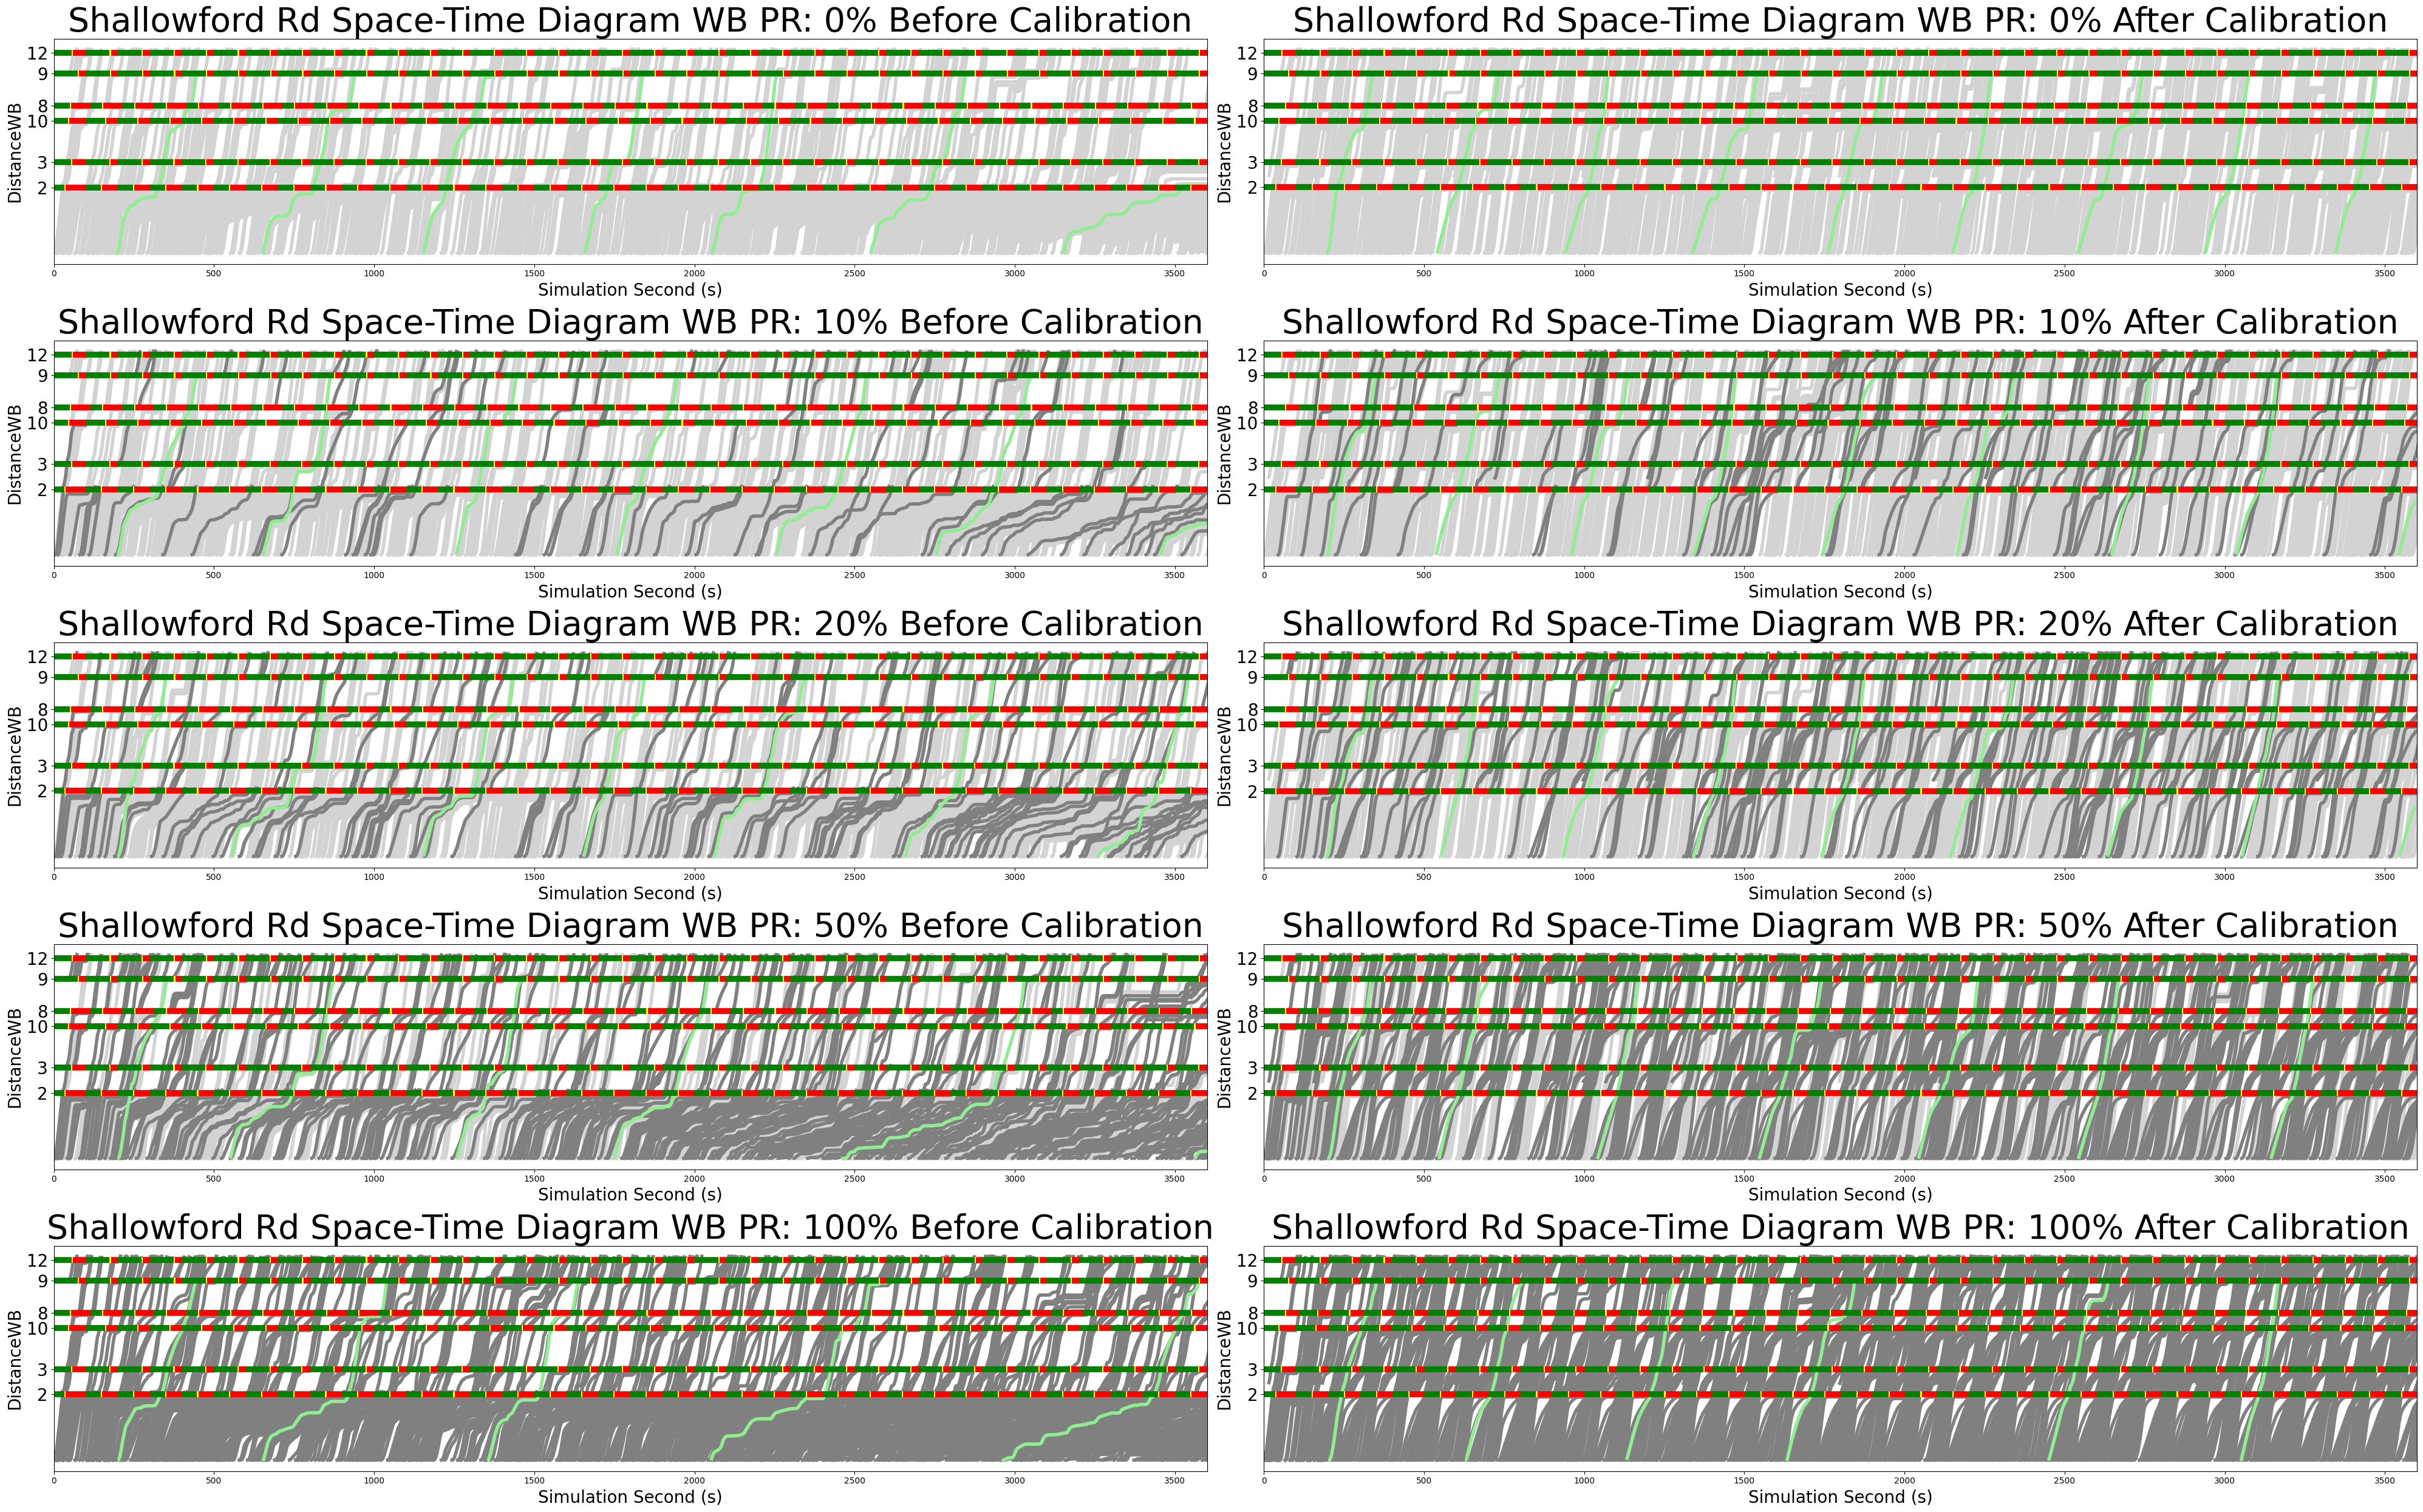

<Figure size 640x480 with 0 Axes>

C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\820437216.py:55: UserWarning: 
The palette list has fewer values (1) than needed (1471) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'HDV'], x='time', y='distance', hue='id', legend=False, palette=['lightgrey'])
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\820437216.py:56: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'CAV'], x='time', y='distance', hue='id', legend=False, palette=['grey'])
C:\Users\hg25079\AppData\Local\Temp\ipykernel_66144\2128674271.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.

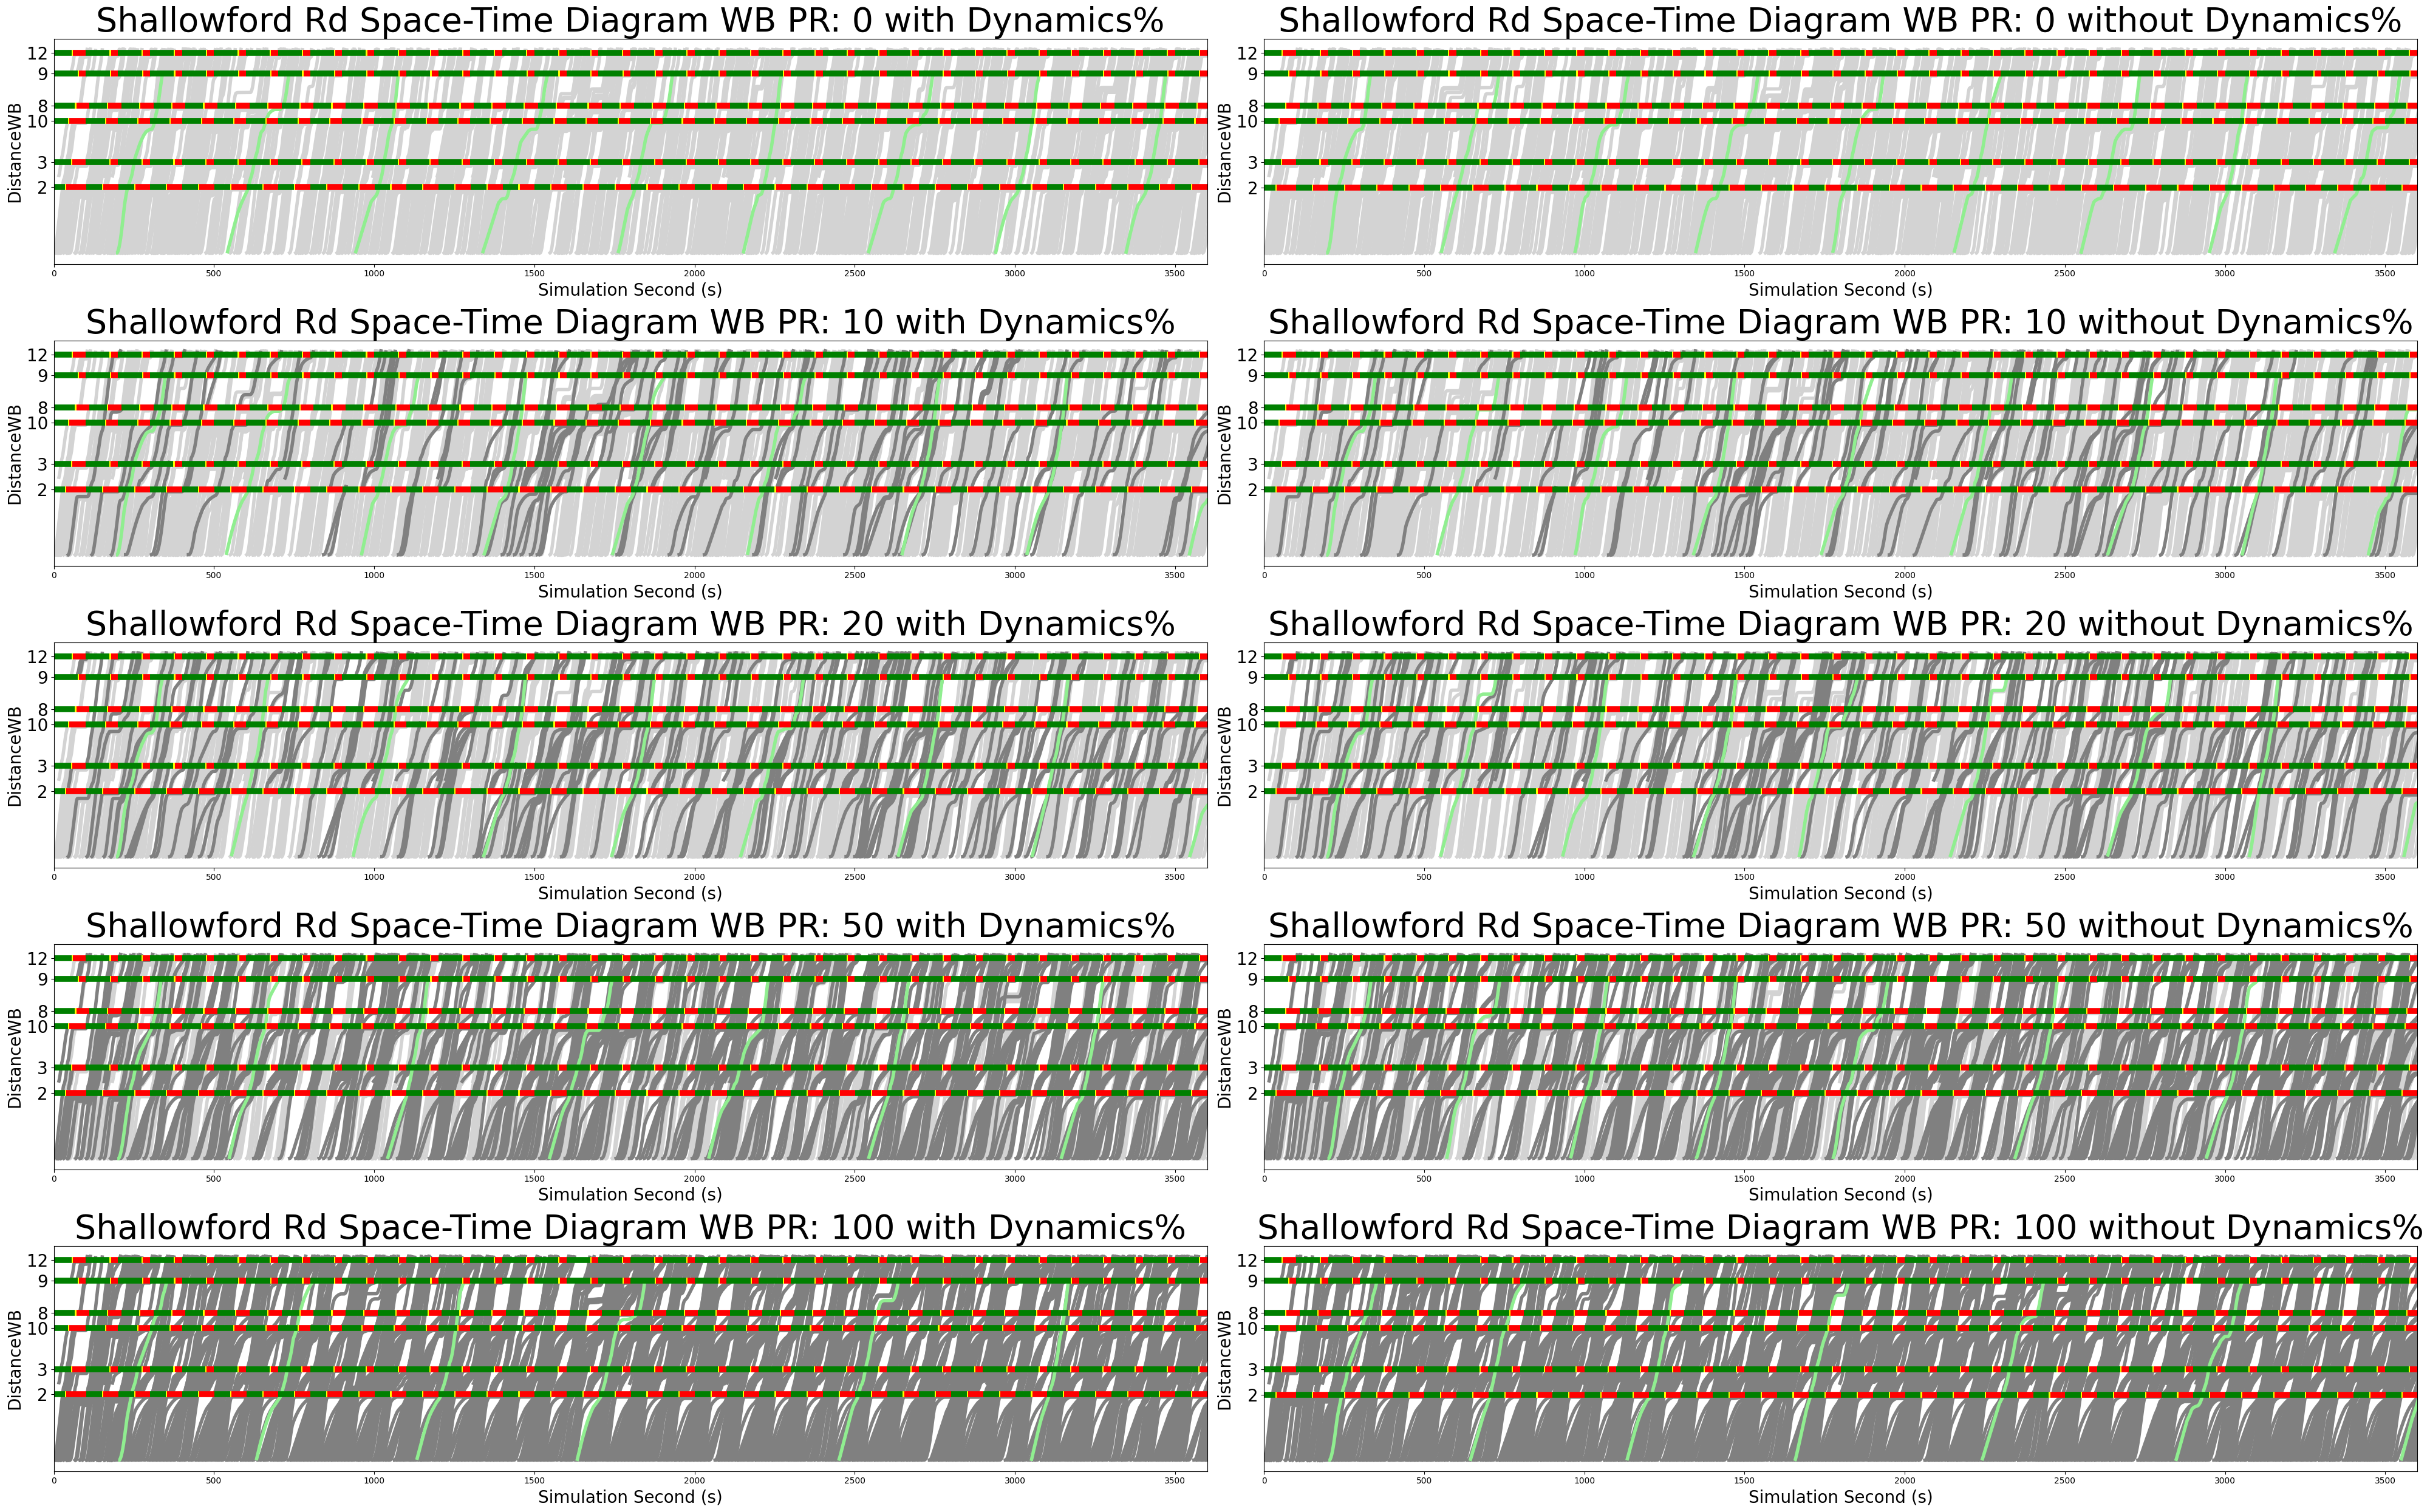

In [24]:
def plot_signal_changes_xml(ax, sumosignalresult, sumoSignalConfig, direction='EB', extra_label=""):
    
    sumoSignalConfig = sumoSignalConfig[sumoSignalConfig['approach_direction'] == direction].reset_index(drop=True)
    if direction == 'WB':
        sumoSignalConfig['distance'] = sumoSignalConfig['distance_wb']
    elif direction == 'EB':
        sumoSignalConfig['distance'] = sumoSignalConfig['distance_eb']
    for sc in sumoSignalConfig.id.unique():
        
        phase_num = sumoSignalConfig[sumoSignalConfig['id'] == sc]['name'].values[0]
        movement_indexes = eval(sumoSignalConfig[sumoSignalConfig['id'] == sc]['movement_index'].values[0])
        x_loc = sumoSignalConfig[sumoSignalConfig['id'] == sc]['distance'].values[0]

        signal_changes_tem = sumosignalresult[sumosignalresult['id'] == sc].reset_index(drop=True)
        signal_changes_tem['target_phase_state'] = signal_changes_tem['state'].str[movement_indexes[0]: movement_indexes[0] + 1]

        # only keep phase changes for the targeted phase
        signal_changes_tem = signal_changes_tem[signal_changes_tem['target_phase_state'] != signal_changes_tem['target_phase_state'].shift()]
        signal_changes_tem['target_phase_state'] = signal_changes_tem['target_phase_state'].map({'G': 'green', 'g': 'green', 'y': 'yellow', 'r': 'red', 's': 'red'})
        
        cnt = 1
        prev_idx = 0
        prev_clr = signal_changes_tem.loc[prev_idx,'target_phase_state']
        
        for index, row in signal_changes_tem.iterrows():
            if index >= 1:
                
                y1 = [x_loc, x_loc]
                x1 = [float(signal_changes_tem.loc[prev_idx,'time']), float(row.time)]
                ax.plot(x1, y1, color=prev_clr, linewidth=7, solid_capstyle='butt')
                c = row.target_phase_state

                prev_idx = index
                prev_clr = c
                cnt += 1
            else:
                continue

    ax.set_title(f'Shallowford Rd Space-Time Diagram {direction} {extra_label}')
    ax.set_xlabel('Simulation Second (s)', fontsize=20)
    ax.set_ylabel(f'Distance{direction}', fontsize=20)
    # ax.set_xlim(plot_start_time, plot_start_time + duration_limit)
    ax.set_yticks(sumoSignalConfig['distance'].values)
    ax.set_yticklabels(sumoSignalConfig['id'].values, fontsize=20)
    # ax.invert_yaxis()
    return ax
def plot_trajectory(ax, trajectory_data, highlight_veh_number='None', plot_start_time=29000, plot_end_time=32400):
    line_width = 1
    trajectory_data['time'] = trajectory_data['time'].astype(float)
    trajectory_data['distance'] = trajectory_data['distance'].astype(float)
    highlight_veh_data = trajectory_data[trajectory_data['id'] == highlight_veh_number]
    trajectory_data = trajectory_data[trajectory_data['id'] != highlight_veh_number]


    sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'HDV'], x='time', y='distance', hue='id', legend=False, palette=['lightgrey'])
    sns.lineplot(ax=ax, data=trajectory_data[trajectory_data['type'] == 'CAV'], x='time', y='distance', hue='id', legend=False, palette=['grey'])
    
    highlight_veh_data = assign_trip_id(highlight_veh_data, 100)
    # highlight a specific vehicle
    if highlight_veh_number != 'None':
        
        clr = 'lightgreen'
        line_width = 4
        for group_name, group in highlight_veh_data.groupby('tripId'):
            ax.plot(group['time'].astype(float), group['distance'].astype(float), color=clr, linewidth=line_width, solid_capstyle='butt')
    ax.set_xlim(0, 3600)
    return ax


from cav_casestudy.SUMO.spaceTimePlotWithSignals import  read_trajectory_xml, read_signal_xml, trajectory_process
# import sns
import seaborn as sns
def plot_space_time_diagram_calibration(data_dic_before_calibration, data_dic_after_calibration):
    setting_cnt = len(data_dic_before_calibration)
    fig, axes = plt.subplots(setting_cnt, 2, figsize=(40, 5 * setting_cnt))
    # plot the west bound first
    for idx, pr in enumerate(data_dic_before_calibration.keys()):
        path_before_calibration = data_dic_before_calibration[pr]['path']
        sumo_signal_before_calibration = read_signal_xml(os.path.join(path_before_calibration, 'signal_result.xml'))
        sumoSignalConfig_before_calibration = data_dic_before_calibration[pr]['sumo_signal_config']
        trajectory_data_wb_before_calibration = read_trajectory_xml(os.path.join(path_before_calibration, 'fcd.xml'), refer_coord=refer_coord_wb)

        path_after_calibration = data_dic_after_calibration[pr]['path']
        sumo_signal_after_calibration = read_signal_xml(os.path.join(path_after_calibration, 'signal_result.xml'))
        sumoSignalConfig_after_calibration = data_dic_after_calibration[pr]['sumo_signal_config']
        trajectory_data_wb_after_calibration = read_trajectory_xml(os.path.join(path_after_calibration, 'fcd.xml'), refer_coord=refer_coord_wb)

        wb_lanes = ['-2801', '-280', '-307', '-327', '-281', '-315', '-321', '-300', '-2851', '-285', '-290', '-298', '-295']
        eb_lanes = ['-312', '-293', '-297', '-288', '-286', '-302', '-3221', '-322', '-313', '-284', '-328', '-304']
        relative_time = 28800
        sumo_signal_before_calibration['time'] = sumo_signal_before_calibration['time'].astype(float) - relative_time
        sumo_signal_after_calibration['time'] = sumo_signal_after_calibration['time'].astype(float) - relative_time

        
        
        
        trajectory_data_wb_before_calibration = trajectory_process(trajectory_data_wb_before_calibration, eb_lanes, wb_lanes, relative_time)
        trajectory_data_wb_after_calibration = trajectory_process(trajectory_data_wb_after_calibration, eb_lanes, wb_lanes, relative_time)

        trajectory_data_wb_after_calibration = trajectory_data_wb_after_calibration[trajectory_data_wb_after_calibration['direction'] == 'WB'].reset_index(drop=True)
        trajectory_data_wb_before_calibration = trajectory_data_wb_before_calibration[trajectory_data_wb_before_calibration['direction'] == 'WB'].reset_index(drop=True)


        axes[idx][0] = plot_trajectory(axes[idx][0], trajectory_data_wb_before_calibration, highlight_veh_number='ego')
        axes[idx][0] = plot_signal_changes_xml(axes[idx][0], sumo_signal_before_calibration, sumoSignalConfig_before_calibration, direction='WB', extra_label=f'PR: {pr:.0f}% Before Calibration')

        
        axes[idx][1]  = plot_trajectory(axes[idx][1], trajectory_data_wb_after_calibration, highlight_veh_number='ego')
        axes[idx][1] = plot_signal_changes_xml(axes[idx][1], sumo_signal_after_calibration, sumoSignalConfig_after_calibration, direction='WB', extra_label=f'PR: {pr:.0f}% After Calibration')
    plt.tight_layout()
    plt.show()
    

    plt.tight_layout()
    plt.show()




def plot_space_time_diagram_dynamics(data_dic_with_dynamics, data_dic_without_dynamics):
    setting_cnt = len(data_dic_with_dynamics)
    fig, axes = plt.subplots(setting_cnt, 2, figsize=(40, 5 * setting_cnt))
    # plot the west bound first
    for idx, pr in enumerate(data_dic_with_dynamics.keys()):
        path_with_dynamics = data_dic_with_dynamics[pr]['path']
        sumo_signal_with_dynamics = read_signal_xml(os.path.join(path_with_dynamics, 'signal_result.xml'))
        sumoSignalConfig_with_dynamics = data_dic_with_dynamics[pr]['sumo_signal_config']
        trajectory_data_wb_with_dynamics = read_trajectory_xml(os.path.join(path_with_dynamics, 'fcd.xml'), refer_coord=refer_coord_wb)

        path_wiout_dynamics = data_dic_without_dynamics[pr]['path']
        sumo_signal_without_dynamics = read_signal_xml(os.path.join(path_wiout_dynamics, 'signal_result.xml'))
        sumoSignalConfig_without_dynamics = data_dic_without_dynamics[pr]['sumo_signal_config']
        trajectory_data_wb_without_dynamics = read_trajectory_xml(os.path.join(path_wiout_dynamics, 'fcd.xml'), refer_coord=refer_coord_wb)

        wb_lanes = ['-2801', '-280', '-307', '-327', '-281', '-315', '-321', '-300', '-2851', '-285', '-290', '-298', '-295']
        eb_lanes = ['-312', '-293', '-297', '-288', '-286', '-302', '-3221', '-322', '-313', '-284', '-328', '-304']
        relative_time = 28800
        sumo_signal_with_dynamics['time'] = sumo_signal_with_dynamics['time'].astype(float) - relative_time
        sumo_signal_without_dynamics['time'] = sumo_signal_without_dynamics['time'].astype(float) - relative_time
        
        trajectory_data_wb_with_dynamics = trajectory_process(trajectory_data_wb_with_dynamics, eb_lanes, wb_lanes, relative_time)
        trajectory_data_wb_without_dynamics = trajectory_process(trajectory_data_wb_without_dynamics, eb_lanes, wb_lanes, relative_time)

        trajectory_data_wb_with_dynamics = trajectory_data_wb_with_dynamics[trajectory_data_wb_with_dynamics['direction'] == 'WB'].reset_index(drop=True)
        trajectory_data_wb_without_dynamics = trajectory_data_wb_without_dynamics[trajectory_data_wb_without_dynamics['direction'] == 'WB'].reset_index(drop=True)

        
        axes[idx][0] = plot_trajectory(axes[idx][0], trajectory_data_wb_with_dynamics, highlight_veh_number='ego')
        axes[idx][0] = plot_signal_changes_xml(axes[idx][0], sumo_signal_with_dynamics, sumoSignalConfig_with_dynamics, direction='WB', extra_label=f'PR: {pr:.0f} with Dynamics%')

        
        axes[idx][1]  = plot_trajectory(axes[idx][1], trajectory_data_wb_without_dynamics, highlight_veh_number='ego')
        axes[idx][1] = plot_signal_changes_xml(axes[idx][1], sumo_signal_without_dynamics, sumoSignalConfig_without_dynamics, direction='WB', extra_label=f'PR: {pr:.0f} without Dynamics%')
    
    plt.tight_layout()
    plt.show()

plot_space_time_diagram_calibration(data_dic_with_dynamics_before_calibration, data_dic_with_dynamics_after_calibration)

plot_space_time_diagram_dynamics(data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration)

def plot_space_time_diagram(data_dic, name):
    setting_cnt = len(data_dic)
    fig, axes = plt.subplots(setting_cnt, 2, figsize=(40, 5 * setting_cnt))
    for idx, pr in enumerate(data_dic.keys()):
        sumo_signal = data_dic[pr]['signal_file']
        sumoSignalConfig = data_dic[pr]['sumo_signal_config']
        trajectory_data_wb = data_dic[pr]['trajectory_data_wb']
        trajectory_data_eb = data_dic[pr]['trajectory_data_eb']
        label = f'PR: {pr:.0f} {name}%'
        
        axes[idx][0] = plot_trajectory(axes[idx][0], trajectory_data_wb, 100, highlight_veh_number='ego')
        axes[idx][0] = plot_signal_changes_xml(axes[idx][0], sumo_signal, sumoSignalConfig, direction='WB', extra_label=label)

        
        axes[idx][1]  = plot_trajectory(axes[idx][1], trajectory_data_eb, 100, highlight_veh_number='ego')
        axes[idx][1] = plot_signal_changes_xml(axes[idx][1], sumo_signal, sumoSignalConfig, direction='EB', extra_label=label)

    plt.tight_layout()
    
def plot_profiles(data_dic, unit_dic, name):
    # drop the last trip
    # eco_profile = eco_profile[eco_profile['Trip_ID'] != eco_profile['Trip_ID'].iloc[-1]]
    # baseline_profile = baseline_profile[baseline_profile['Trip_ID'] != baseline_profile['Trip_ID'].iloc[-1]]
    data_fileds_num = len(unit_dic)
    fig, axs = plt.subplots(data_fileds_num, 1, figsize=(40, 5 * data_fileds_num))
    # set the title for the plot
    fig.suptitle(name, fontsize=20)
    for i, (field, unit) in enumerate(unit_dic.items()):
        # plot the data for each direction with different color
        # for group_name, group in eco_profile.groupby('Trip_ID'):
        #     axs[i].plot(group['Time'], group[field], label='EcoDriving')
        for pr in data_dic.keys():
            eco_profile = data_dic[pr]['ego_profile']
            pr = f"Penetration Rate: {pr:.0f} %"
            axs[i].plot(eco_profile['Time'], eco_profile[field], label=pr)
            axs[i].set_ylabel(unit)
            axs[i].set_xlabel('Time (s)')
            axs[i].legend()
            axs[i].grid()
    plt.tight_layout()
    # plt.savefig(f'{name}.png')



def plot_sub_profiles(eco_profile, eco_trip_id, baseline_profile, baseline_trip_id, unit_dic, name, direction='WB'):
    eco_profile = eco_profile[eco_profile['Trip_ID'] == eco_trip_id]
    baseline_profile = baseline_profile[baseline_profile['Trip_ID'] == baseline_trip_id]
    eco_profile = eco_profile[eco_profile['Direction'] == direction]
    baseline_profile = baseline_profile[baseline_profile['Direction'] == direction]
    
    data_fileds_num = len(unit_dic)
    fig, axs = plt.subplots(data_fileds_num, 1, figsize=(40, 5 * data_fileds_num))
    for i, (field, unit) in enumerate(unit_dic.items()):
        axs[i].plot(eco_profile['Time'], eco_profile[field], label='EcoDriving')
        axs[i].plot(baseline_profile['Time'], baseline_profile[field], label='Baseline')
        axs[i].set_ylabel(unit)
        axs[i].set_xlabel('Time (s)')
        axs[i].legend()
        axs[i].grid()
    plt.tight_layout()
    # plt.savefig(f'{name}.png')


In [ ]:
ev_unit_dic = {'DesiredSpeed': 'Desired Speed (m/s)', 
                'ActualSpeed' : 'Actual Speed (m/s)', 
                'MPGe' : 'MPGe',
                'BatteryPower': 'Battery Power (W)', 
                'MotorSpeed': 'Motor Speed (rad/s)', 
                'MotorTorque': 'Motor Torque (Nm)', 
                'BatterySOC': 'State of Charge (%)', 
                'BatteryCurrent': 'Current (A)',
                # 'Distance': 'Distance (m)',
                # 'EnergyConsumption': 'Energy Consumption (KWH)',
                }

icv_unit_dic = {'DesiredSpeed' : 'Desired Speed (m/s)',
                'ActualSpeed' : 'Actual Speed (m/s)',
                'MPG': 'MPG', 
                'FuelConsumptionRate': 'Fuel Rate (m^3/s)',
                'EngineSpeed' : 'Engine Speed (rad/s)', 
                'EngineTorque' : 'Engine Torque (Nm)',
                # 'FuelConsumption': 'Fuel Consumption (m^3)',
                # 'Distance': 'Distance (m)',
                }

# plot_sub_profiles(eco_icv_profile, 3, baseline_icv_profile, 3, icv_unit_dic, 'ICV_Trip_1', direction='WB')
# plot_profiles(data_dic=data_dic_with_dynamics, unit_dic=ev_unit_dic, name='EV')
# plot_profiles(data_dic=data_dic_without_dynamics, unit_dic=ev_unit_dic, name='Baseline')
# plot_profiles(data_dic=data_dic_without_dynamics, unit_dic=ev_unit_dic, name='Baseline')
# plot_space_time_diagram(data_dic_with_dynamics, 'With Dynamics')
# plot_space_time_diagram_calibration(data_dic_with_dynamics_before_calibration, data_dic_with_dynamics_after_calibration)
plot_space_time_diagram_calibration(data_dic_with_dynamics_before_calibration, data_dic_with_dynamics_after_calibration)
plot_space_time_diagram_dynamics(data_dic_with_dynamics_after_calibration, data_dic_without_dynamics_after_calibration)

# plot_profiles(eco_icv_profile, baseline_icv_profile, icv_unit_dic, 'ICV')
# plot_profiles(eco_icv_profile, baseline_icv_profile, ev_unit_dic, 'ICV')
# plot_profiles(eco_ev_profile, baseline_ev_profile, ev_unit_dic, 'EV')

In [ ]:
#data_dic_with_dynamics_before_calibration data_dic_with_dynamics_after_calibration


penetration_rates_to_plot = [0.0, 50.0, 100.0]
trip_max_limit = 4
fig, axes = plt.subplots(len(penetration_rates_to_plot), 2, figsize=(24, 12))


speed_list_total_before_calibration = []
time_list_total_before_calibration = []

speed_list_total_after_calibration = []
time_list_total_after_calibration = []

for idx, penetration_rate in enumerate(penetration_rates_to_plot):
    data_dic_before_calibration = data_dic_with_dynamics_before_calibration[penetration_rate]['trajectory_data_wb']
    data_dic_after_calibration = data_dic_with_dynamics_after_calibration[penetration_rate]['trajectory_data_wb']
    data_dic_before_calibration = data_dic_before_calibration[data_dic_before_calibration['id'] == 'ego']
    data_dic_after_calibration = data_dic_after_calibration[data_dic_after_calibration['id'] == 'ego']
    data_dic_before_calibration = assign_trip_id(data_dic_before_calibration, 100)
    data_dic_after_calibration = assign_trip_id(data_dic_after_calibration, 100)
    
    if len(data_dic_before_calibration['tripId'].unique()) < trip_max_limit:
        trip_limit = len(data_dic_before_calibration['tripId'].unique())
    else:
        trip_limit = trip_max_limit

    if len(data_dic_after_calibration['tripId'].unique()) < trip_max_limit:
        trip_limit = len(data_dic_after_calibration['tripId'].unique())
    else:
        trip_limit = trip_max_limit

    # uniformly pick trip_limit trips, not the first trips, for examople, if there are 10 trips, we pick 2, 4, 6, 8, 10
    
    trip_id_list = data_dic_before_calibration['tripId'].unique()
    trip_id_list = trip_id_list[1::2]
    trip_id_list = trip_id_list[:trip_limit]
    data_dic_before_calibration = data_dic_before_calibration[data_dic_before_calibration['tripId'].isin(trip_id_list)]

    trip_id_list = data_dic_after_calibration['tripId'].unique()
    trip_id_list = trip_id_list[1::2]
    trip_id_list = trip_id_list[:trip_limit]
    data_dic_after_calibration = data_dic_after_calibration[data_dic_after_calibration['tripId'].isin(trip_id_list)]

    speed_list_before_calibration = []
    time_list_before_calibration = []
    for trip_id, group in data_dic_before_calibration.groupby('tripId'):
        speed = group['speed'].astype(float)
        time = group['time'].astype(float)
        
        time_shifted = time - time.iloc[0]
        speed_list_before_calibration.append(speed.values.tolist())
        time_list_before_calibration.append(time_shifted.values.tolist())
    speed_list_total_before_calibration.append(speed_list_before_calibration)
    time_list_total_before_calibration.append(time_list_before_calibration)

    speed_list_after_calibration = []
    time_list_after_calibration = []
    for trip_id, group in data_dic_after_calibration.groupby('tripId'):
        speed = group['speed'].astype(float)
        time = group['time'].astype(float)
        
        time_shifted = time - time.iloc[0]
        speed_list_after_calibration.append(speed.values.tolist())
        time_list_after_calibration.append(time_shifted.values.tolist())
    speed_list_total_after_calibration.append(speed_list_after_calibration)
    time_list_total_after_calibration.append(time_list_after_calibration)


speed_max_limit_before_calibration = max([max(max(speed_list)) for speed_list in speed_list_total_before_calibration])
time_max_limit_before_calibration = max([max(max(time_list)) for time_list in time_list_total_before_calibration])

speed_max_limit_after_calibration = max([max(max(speed_list)) for speed_list in speed_list_total_after_calibration])
time_max_limit_after_calibration = max([max(max(time_list)) for time_list in time_list_total_after_calibration])

speed_max_limit = max(speed_max_limit_before_calibration, speed_max_limit_after_calibration) * 1.4
time_max_limit = max(time_max_limit_before_calibration, time_max_limit_after_calibration)





for idx, penetration_rate in enumerate(penetration_rates_to_plot):
    for i in range(len(speed_list_total_before_calibration[idx])):
        axes[idx][0].plot(time_list_total_before_calibration[idx][i], speed_list_total_before_calibration[idx][i], label=f'')
        
    for i in range(len(speed_list_total_after_calibration[idx])):
        axes[idx][1].plot(time_list_total_after_calibration[idx][i], speed_list_total_after_calibration[idx][i], label=f'')

    axes[idx][0].set_title(f'Ego Vehicle Speed at {penetration_rate} % Before Calibration (With Dynamics)', fontsize=14)
    axes[idx][0].set_title(f'Ego Vehicle Speed at {penetration_rate} % Before Calibration (With Dynamics)', fontsize=14)
    axes[idx][0].set_xlabel('Time (s)', fontsize=12)
    axes[idx][0].set_ylabel('Speed (m/s)', fontsize=12)
    axes[idx][0].set_ylim(0, speed_max_limit)
    axes[idx][0].set_xlim(0, time_max_limit)
    axes[idx][0].grid()

    axes[idx][1].set_title(f'Ego Vehicle Speed at {penetration_rate} % After Calibration (With Dynamics)', fontsize=14)
    axes[idx][1].set_title(f'Ego Vehicle Speed at {penetration_rate} % After Calibration (With Dynamics)', fontsize=14)
    axes[idx][1].set_xlabel('Time (s)', fontsize=12)
    axes[idx][1].set_ylabel('Speed (m/s)', fontsize=12)
    axes[idx][1].set_ylim(0, speed_max_limit)
    axes[idx][1].set_xlim(0, time_max_limit)
    axes[idx][1].grid()

plt.tight_layout()

In [ ]:
print('Before Calibration (WB)')
for penetration_rate, data_dic in data_dic_with_dynamics_before_calibration.items():
    veh_cnt = data_dic['trajectory_data_wb']['id'].nunique()
    print(f'Penetration Rate: {penetration_rate} %, Vehicle Count: {veh_cnt}')
print('After Calibration (WB)')

for penetration_rate, data_dic in data_dic_with_dynamics_after_calibration.items():
    veh_cnt = data_dic['trajectory_data_wb']['id'].nunique()
    print(f'Penetration Rate: {penetration_rate} %, Vehicle Count: {veh_cnt}')

In [ ]:
def get_corridor_veh_cnt(trajectory_data_eco_driving):
    
    trajectory_data_eco_driving = trajectory_data_eco_driving[trajectory_data_eco_driving['time'].astype(float) >= 29000].reset_index(drop=True)
    # only keep the major corridor trajectories
    wb_lanes = ['-2801', '-280', '-307', '-327', '-281', '-315', '-321', '-300', '-2851', '-285', '-290', '-298', '-295']
    eb_lanes = ['-312', '-293', '-297', '-288', '-286', '-302', '-3221', '-322', '-313', '-284', '-328', '-304']
    trajectory_data_eco_driving['segment'] = trajectory_data_eco_driving['lane'].str.split('_').str[0]
    trajectory_data_eco_driving['direction'] = np.where(trajectory_data_eco_driving['segment'].isin(wb_lanes), "WB",
                                            np.where(trajectory_data_eco_driving['segment'].isin(eb_lanes), "EB", None))
    trajectory_data_eco_driving = trajectory_data_eco_driving.sort_values(by=['id', 'time'], ignore_index=True)
    trajectory_data_eco_driving = trajectory_data_eco_driving[(trajectory_data_eco_driving['direction'].notnull())
                                                              | (trajectory_data_eco_driving['segment'].str.contains(':'))]
    # Forward fill and backward fill within each group
    trajectory_data_eco_driving = remove_none_edges(trajectory_data_eco_driving, group_col="id", value_col="direction")
    # Forward fill and backward fill within each group
    trajectory_data_eco_driving["direction"] = trajectory_data_eco_driving.groupby("id")["direction"].ffill()
    trajectory_data_eco_driving = trajectory_data_eco_driving[trajectory_data_eco_driving['direction'].isin(['EB', 'WB'])].reset_index(drop=True)

    return trajectory_data_eco_driving['id'].nunique()
print('Before Calibration (WB)')
for penetration_rate, data_dic in data_dic_with_dynamics_before_calibration.items():
    veh_cnt = get_corridor_veh_cnt(data_dic['trajectory_data_wb'])
    print(f'Penetration Rate: {penetration_rate} %, Vehicle Count: {veh_cnt}')
print('After Calibration (WB)')

for penetration_rate, data_dic in data_dic_with_dynamics_after_calibration.items():
    veh_cnt = get_corridor_veh_cnt(data_dic['trajectory_data_wb'])
    print(f'Penetration Rate: {penetration_rate} %, Vehicle Count: {veh_cnt}')

In [ ]:
print('Before Calibration (WB)')
vtMicroCoeff = pd.read_csv(r'VTMicroCoeff.csv')
df_vehicle_src_coeff = pd.read_csv(r'VehicleSrcCoeff.csv')
for penetration_rate, data_dic in data_dic_with_dynamics_before_calibration.items():
    (trajectory_data_energy_sum, system_fuel_consume_vt_cpmf_liter, system_fuel_consume_vt_micro_liter, system_energy_consume_tractive_kj,
            system_energy_consume_tractive_regen_kj, system_travel_dist_m, system_travel_dist2_m, system_travel_time_s) = get_traj_eval(data_dic['trajectory_data_wb'], 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')
    print(f'Penetration Rate: {penetration_rate} %, Mean Speed: {system_travel_dist2_m / system_travel_time_s * 2.23694} mph')
print('After Calibration (WB)')

for penetration_rate, data_dic in data_dic_with_dynamics_after_calibration.items():
    (trajectory_data_energy_sum, system_fuel_consume_vt_cpmf_liter, system_fuel_consume_vt_micro_liter, system_energy_consume_tractive_kj,
            system_energy_consume_tractive_regen_kj, system_travel_dist_m, system_travel_dist2_m, system_travel_time_s) = get_traj_eval(data_dic['trajectory_data_wb'], 1, vtMicroCoeff, df_vehicle_src_coeff, veh_no='system')
    print(f'Penetration Rate: {penetration_rate} %, Mean Speed: {system_travel_dist2_m / system_travel_time_s * 2.23694} mph')